In [5]:
# -*- coding: utf-8 -*-
"""
TINKERING PROJECT: Macro Regime-Detection with HMM
(PATCHED - Fixes the "all scalar values" pandas error)
"""

import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn import hmm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

print("📥 Downloading data... (This might take 10 seconds)")

# ------------------- 1. FETCH MACRO DATA (TINKER-PROOF) -------------------
print("📥 Downloading data... (This might take 10 seconds)")

# Download each ticker as a Series (using .squeeze() to flatten any accidental DataFrames)
spy = yf.download("SPY", start="2015-01-01", end="2025-01-01", progress=False)['Close'].squeeze()
vix = yf.download("^VIX", start="2015-01-01", end="2025-01-01", progress=False)['Close'].squeeze()
hyg = yf.download("HYG", start="2015-01-01", end="2025-01-01", progress=False)['Close'].squeeze()
lqd = yf.download("LQD", start="2015-01-01", end="2025-01-01", progress=False)['Close'].squeeze()
dxy = yf.download("DX-Y.NYB", start="2015-01-01", end="2025-01-01", progress=False)['Close'].squeeze()

# Build DataFrame column-by-column (NO dictionary, NO concat keys complexity)
data = pd.DataFrame(index=spy.index)  # Use SPY's datetime index as the master
data['SPY'] = spy
data['VIX'] = vix
data['HYG'] = hyg
data['LQD'] = lqd
data['DXY'] = dxy

# Drop any rows where ANY ticker is missing (ensures perfect alignment)
data = data.dropna()

if data.empty:
    print("❌ ERROR: No data downloaded. Check your ticker symbols or internet.")
    exit()

print(f"✅ Data shape: {data.shape} rows from {data.index[0].date()} to {data.index[-1].date()}")

📥 Downloading data... (This might take 10 seconds)
📥 Downloading data... (This might take 10 seconds)
✅ Data shape: (2514, 5) rows from 2015-01-02 to 2024-12-31


In [6]:
# ------------------- 2. ENGINEER "TINKERABLE" FEATURES -------------------
# Feature 1: SPY 21-day returns (momentum)
data['SPY_ret'] = data['SPY'].pct_change(21)
# Feature 2: Change in VIX (flight-to-safety)
data['VIX_diff'] = data['VIX'].diff()
# Feature 3: Credit Spread widening (HYG - LQD). Spread WIDENING = Stress.
data['Credit_Spread'] = data['HYG'] / data['LQD']  # Ratio falls during crises
data['Spread_diff'] = data['Credit_Spread'].diff()
# Feature 4: DXY strength (risk-off tends to strengthen USD)
data['DXY_diff'] = data['DXY'].diff()

# Drop initial NaNs
features = data[['SPY_ret', 'VIX_diff', 'Spread_diff', 'DXY_diff']].dropna()
dates = features.index

# Standardize features (crucial for HMM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print(f"✅ Features shape: {X_scaled.shape}")

✅ Features shape: (2493, 4)


In [15]:
# ------------------- 2.5 DEFINE & TRAIN THE HMM MODEL -------------------
# TINKER POINT: Change n_components (2, 3, or 4) or covariance_type
model = hmm.GaussianHMM(
    n_components=5,           # Try 2 or 4 to see regimes change!
    covariance_type="full",   # Try "diag" or "spherical"
    n_iter=500,
    random_state=42
)
model.fit(X_scaled)

# Predict the hidden regimes
hidden_states = model.predict(X_scaled)

print(f"✅ HMM trained. Hidden states shape: {hidden_states.shape}")
print(f"   Unique states found: {np.unique(hidden_states)}")

✅ HMM trained. Hidden states shape: (2493,)
   Unique states found: [0 1 2 3 4]


In [16]:
# ------------------- 3. MAP REGIMES (TINKER-PROOF ALIGNMENT) -------------------
# Calculate average 21-day SPY return for each hidden state
# We use 'features' because it is already perfectly aligned with 'hidden_states' (NO slicing needed!)
state_means = []
for i in range(model.n_components):
    mask = (hidden_states == i)
    avg_return = np.mean(features['SPY_ret'].values[mask])
    state_means.append(avg_return)

# Sort states: lowest avg return = Crisis (0), highest = Bull (2)
regime_map = {i: idx for idx, i in enumerate(np.argsort(state_means))}
mapped_states = np.array([regime_map[s] for s in hidden_states])

# Assign back to the main 'data' DataFrame using the aligned 'dates' index
data['Regime'] = np.nan
data.loc[dates, 'Regime'] = mapped_states  # 'dates' matches 'features' index perfectly

print(f"✅ Regime mapping complete. Crisis count: {np.sum(mapped_states==0)}, Normal: {np.sum(mapped_states==1)}, Bull: {np.sum(mapped_states==2)}")

✅ Regime mapping complete. Crisis count: 513, Normal: 84, Bull: 732


In [17]:
# ------------------- 4. OVERLAY STRATEGY (TINKER WITH THIS!) ----------------
# Tinker Point 1: Change the SMA periods (e.g., 10/30 or 100/200)
short_sma = data['SPY'].rolling(100).mean()
long_sma = data['SPY'].rolling(200).mean()
data['Momentum_Signal'] = np.where(short_sma > long_sma, 1, 0)

# Tinker Point 2: Only allow trades if Regime is NOT "Crisis" (state 0)
# If Crisis, force position to 0 (cash)
data['Regime_Allow'] = np.where(data['Regime'] == 0, 0, 1)  # 0=Crisis, block trading

# Combined Strategy: Trade Momentum ONLY if Regime allows it
data['Strategy_Position'] = data['Momentum_Signal'] * data['Regime_Allow']
data['Strategy_Return'] = data['SPY'].pct_change() * data['Strategy_Position'].shift(1)
data['Buy_Hold_Return'] = data['SPY'].pct_change()


📊 TINKERING BACKTEST RESULTS
🚀 Strategy Total Return: 111.08%
📈 Buy & Hold Total Return: 239.57%
🛡️ Strategy Max Drawdown: 29.64%
💀 Buy & Hold Max Drawdown: 33.72%


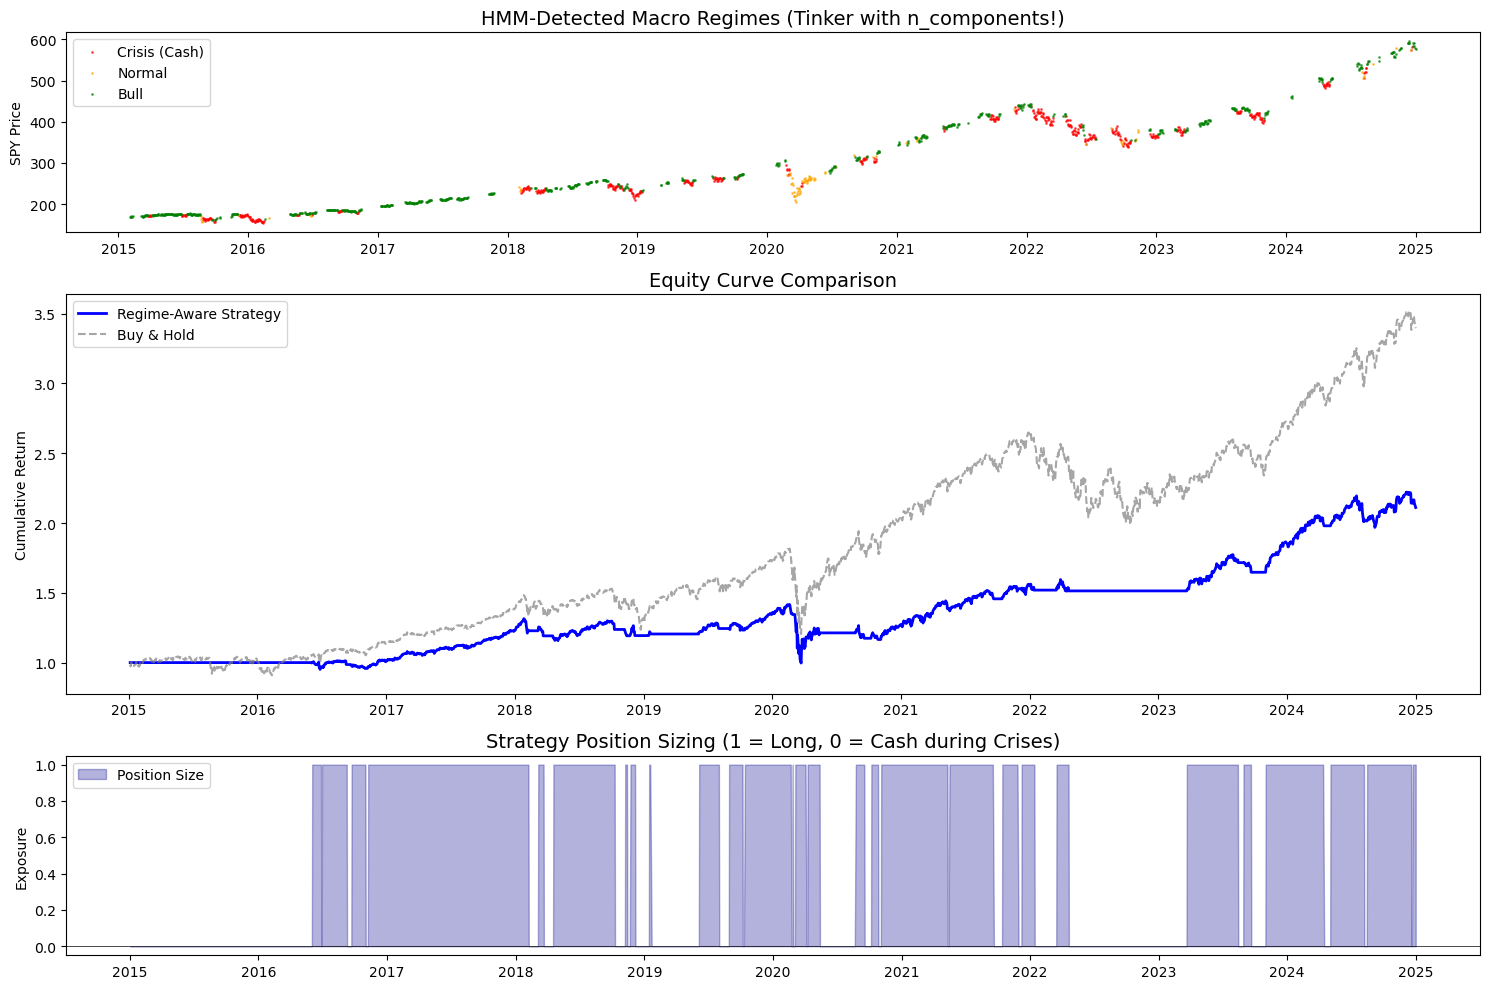

In [18]:
# ------------------- 5. PERFORMANCE COMPARISON ---------------------------
# Calculate cumulative returns (starting from 1)
data['Strategy_Cum'] = (1 + data['Strategy_Return']).cumprod()
data['BH_Cum'] = (1 + data['Buy_Hold_Return']).cumprod()

# Drop initial NaN
results = data[['Strategy_Cum', 'BH_Cum']].dropna()

total_return_strat = (results['Strategy_Cum'].iloc[-1] - 1) * 100
total_return_bh = (results['BH_Cum'].iloc[-1] - 1) * 100

# Risk Metrics
strat_dd = (results['Strategy_Cum'].cummax() - results['Strategy_Cum']) / results['Strategy_Cum'].cummax()
bh_dd = (results['BH_Cum'].cummax() - results['BH_Cum']) / results['BH_Cum'].cummax()

print("\n" + "="*50)
print("📊 TINKERING BACKTEST RESULTS")
print("="*50)
print(f"🚀 Strategy Total Return: {total_return_strat:.2f}%")
print(f"📈 Buy & Hold Total Return: {total_return_bh:.2f}%")
print(f"🛡️ Strategy Max Drawdown: {strat_dd.max()*100:.2f}%")
print(f"💀 Buy & Hold Max Drawdown: {bh_dd.max()*100:.2f}%")

# Plot the Regimes and Equity Curves
fig, axes = plt.subplots(3, 1, figsize=(15, 10), gridspec_kw={'height_ratios': [1, 2, 1]})

# Plot 1: Regimes over time
colors = ['red', 'orange', 'green']
labels = ['Crisis (Cash)', 'Normal', 'Bull']
for i in range(3):
    mask = (data['Regime'] == i)
    axes[0].scatter(data.index[mask], data['SPY'][mask], 
                    c=colors[i], label=labels[i], s=1, alpha=0.6)
axes[0].set_title('HMM-Detected Macro Regimes (Tinker with n_components!)', fontsize=14)
axes[0].legend()
axes[0].set_ylabel('SPY Price')

# Plot 2: Equity Curves
axes[1].plot(results.index, results['Strategy_Cum'], label='Regime-Aware Strategy', color='blue', linewidth=2)
axes[1].plot(results.index, results['BH_Cum'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.7)
axes[1].set_title('Equity Curve Comparison', fontsize=14)
axes[1].legend()
axes[1].set_ylabel('Cumulative Return')

# Plot 3: Strategy Position size over time
axes[2].fill_between(data.index, 0, data['Strategy_Position'], 
                     color='darkblue', alpha=0.3, label='Position Size')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[2].set_title('Strategy Position Sizing (1 = Long, 0 = Cash during Crises)', fontsize=14)
axes[2].legend()
axes[2].set_ylabel('Exposure')

plt.tight_layout()
plt.show()

In [19]:
# ------------------- 6. TINKERING INSTRUCTIONS (READ THIS) ----------------
print("\n" + "🔧 HOW TO TINKER WITH THIS PROJECT:")
print("="*50)
print("1. Change `n_components=3` to `2` or `4` -> see how regimes split/merge.")
print("2. Change `covariance_type='full'` to `'diag'` (faster, less overfitting).")
print("3. Replace features: add 'US2Y-10Y Yield Spread' from yfinance (^TNX, ^FVX).")
print("4. Change the overlay strategy: e.g., trade only VIX futures or TQQQ/SQQQ.")
print("5. Turn this into a rolling-window: fit HMM on last 252 days, not full history.")


🔧 HOW TO TINKER WITH THIS PROJECT:
1. Change `n_components=3` to `2` or `4` -> see how regimes split/merge.
2. Change `covariance_type='full'` to `'diag'` (faster, less overfitting).
3. Replace features: add 'US2Y-10Y Yield Spread' from yfinance (^TNX, ^FVX).
4. Change the overlay strategy: e.g., trade only VIX futures or TQQQ/SQQQ.
5. Turn this into a rolling-window: fit HMM on last 252 days, not full history.
